# MediSense — Model 2: LSTM Temporal Symptom Progression

This is the **core innovation** of MediSense.
Tracks day-by-day symptom changes to detect disease progression patterns.

**Run from:** `medisense/notebooks/` folder

**Before running:** Make sure `02_symptom_model.ipynb` is done (needs `processed/` files)

In [1]:
import numpy as np
import json
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')
print('✓ Libraries loaded')

TensorFlow : 2.21.0
GPU        : []
✓ Libraries loaded


In [2]:
# ── Paths ─────────────────────────────────────────────────
PROCESSED = Path('../backend/data/processed')
MODEL_DIR = Path('../backend/data/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

with open(PROCESSED / 'disease_symptoms.json') as f:
    disease_symptoms = json.load(f)

with open(PROCESSED / 'all_symptoms.json') as f:
    all_symptoms = json.load(f)

diseases   = list(disease_symptoms.keys())
N_SYMPTOMS = len(all_symptoms)
N_DISEASES = len(diseases)

print(f'Diseases  : {N_DISEASES}')
print(f'Symptoms  : {N_SYMPTOMS}')

Diseases  : 41
Symptoms  : 131


In [3]:
# ── Generate Temporal Sequences ───────────────────────────
# Key idea: diseases follow symptom progression patterns
# Day 1 → early symptoms
# Day 2-3 → more symptoms appear
# Day 4-7 → peak severity

np.random.seed(42)
MAX_DAYS  = 7
N_SAMPLES = 120   # sequences per disease

# Disease-specific progression templates
PROGRESSION = {
    'Common Cold':         {'early': ['continuous_sneezing','runny_nose'],      'late': ['cough','headache','fatigue']},
    'Pneumonia':           {'early': ['mild_fever','cough'],                    'late': ['high_fever','breathlessness','chest_pain']},
    'Dengue':              {'early': ['high_fever','headache'],                 'late': ['skin_rash','joint_pain','vomiting']},
    'Typhoid':             {'early': ['mild_fever','headache'],                 'late': ['high_fever','abdominal_pain','constipation']},
    'Malaria':             {'early': ['chills','shivering'],                    'late': ['high_fever','sweating','headache','vomiting']},
    'Chicken pox':         {'early': ['mild_fever','fatigue'],                  'late': ['skin_rash','itching','red_spots_over_body']},
    'Heart attack':        {'early': ['chest_pain'],                            'late': ['sweating','breathlessness','vomiting']},
    'Jaundice':            {'early': ['fatigue','nausea'],                      'late': ['yellowish_skin','dark_urine','abdominal_pain']},
    'Tuberculosis':        {'early': ['cough','mild_fever'],                    'late': ['blood_in_sputum','weight_loss','breathlessness']},
    'Diabetes ':           {'early': ['fatigue','excessive_hunger'],            'late': ['polyuria','weight_loss','blurred_and_distorted_vision']},
    'Bronchial Asthma':    {'early': ['cough','fatigue'],                       'late': ['breathlessness','high_fever','mucoid_sputum']},
    'Hypertension ':       {'early': ['headache','dizziness'],                  'late': ['chest_pain','loss_of_balance']},
    'Migraine':            {'early': ['headache','acidity'],                    'late': ['blurred_and_distorted_vision','stiff_neck','vomiting']},
    'Fungal infection':    {'early': ['itching'],                               'late': ['skin_rash','nodal_skin_eruptions','dischromic_patches']},
    'Allergy':             {'early': ['continuous_sneezing','shivering'],       'late': ['chills','watering_from_eyes']},
}

def make_sequence(disease, n_days=MAX_DAYS):
    base = disease_symptoms[disease]
    tmpl = PROGRESSION.get(disease.strip(), None)
    seq  = []
    active = set()

    for day in range(1, n_days + 1):
        vec = np.zeros(N_SYMPTOMS)

        if tmpl:
            if day <= 2:
                for s in tmpl['early']:
                    if s in all_symptoms: active.add(s)
            if day >= 3:
                for s in tmpl['late']:
                    if s in all_symptoms: active.add(s)
        else:
            n_reveal = max(1, int(len(base) * day / n_days))
            for s in base[:n_reveal]:
                if s in all_symptoms: active.add(s)

        # Always add some base symptoms
        for s in np.random.choice(base, size=min(3, len(base)), replace=False):
            if s in all_symptoms: active.add(s)

        sev = min(1.0, 0.3 + day * 0.1 + np.random.normal(0, 0.05))
        for s in active:
            vec[all_symptoms.index(s)] = sev

        seq.append(vec)

    return np.array(seq)


X_seq, y_seq = [], []
for disease in diseases:
    for _ in range(N_SAMPLES):
        n_days = np.random.randint(2, MAX_DAYS + 1)
        seq    = make_sequence(disease, n_days)
        # Pad to MAX_DAYS
        if n_days < MAX_DAYS:
            pad = np.zeros((MAX_DAYS - n_days, N_SYMPTOMS))
            seq = np.vstack([seq, pad])
        X_seq.append(seq)
        y_seq.append(disease)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(f'Sequence shape : {X_seq.shape}')   # (n_samples, MAX_DAYS, N_SYMPTOMS)
print(f'Labels shape   : {y_seq.shape}')

Sequence shape : (4920, 7, 131)
Labels shape   : (4920,)


In [4]:
# ── Encode + Split ────────────────────────────────────────
le    = LabelEncoder()
y_enc = le.fit_transform(y_seq)
y_cat = to_categorical(y_enc)

X_tr, X_te, y_tr, y_te, y_tr_raw, y_te_raw = train_test_split(
    X_seq, y_cat, y_enc,
    test_size=0.2, random_state=42, stratify=y_enc
)

print(f'Train : {X_tr.shape}')
print(f'Test  : {X_te.shape}')
print(f'Classes: {len(le.classes_)}')

Train : (3936, 7, 131)
Test  : (984, 7, 131)
Classes: 41


In [5]:
# ── Build LSTM Model ──────────────────────────────────────
N_CLASSES = len(le.classes_)

model = Sequential([
    Masking(mask_value=0.0, input_shape=(MAX_DAYS, N_SYMPTOMS)),
    LSTM(128, return_sequences=True,  dropout=0.2, recurrent_dropout=0.1),
    LSTM(64,  return_sequences=False, dropout=0.2, recurrent_dropout=0.1),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(N_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ masking (Masking)                    │ (None, 7, 131)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 7, 128)              │         133,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 41)                  │           2,665 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 201,769 (788.16 KB)

 Trainable params: 201,769 (788.16 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ── Train ─────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, verbose=1)
]

history = model.fit(
    X_tr, y_tr,
    validation_split=0.15,
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'\n✓ LSTM Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')

Epoch 1/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.1734 - loss: 3.4553 - val_accuracy: 0.5990 - val_loss: 2.5581 - learning_rate: 0.0010
Epoch 2/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6051 - loss: 1.6892 - val_accuracy: 0.9831 - val_loss: 0.5546 - learning_rate: 0.0010
Epoch 3/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8607 - loss: 0.6537 - val_accuracy: 0.9949 - val_loss: 0.2091 - learning_rate: 0.0010
Epoch 4/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9166 - loss: 0.3778 - val_accuracy: 1.0000 - val_loss: 0.1062 - learning_rate: 0.0010
Epoch 5/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9360 - loss: 0.2765 - val_accuracy: 0.9949 - val_loss: 0.0642 - learning_rate: 0.0010
Epoch 6/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9528 - loss: 0.2083 - val_accuracy: 1.0000 - val_loss: 0.0378 - learning_rate: 0.0010
Epoch 7/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9593 - loss: 0.1771 - val_ac

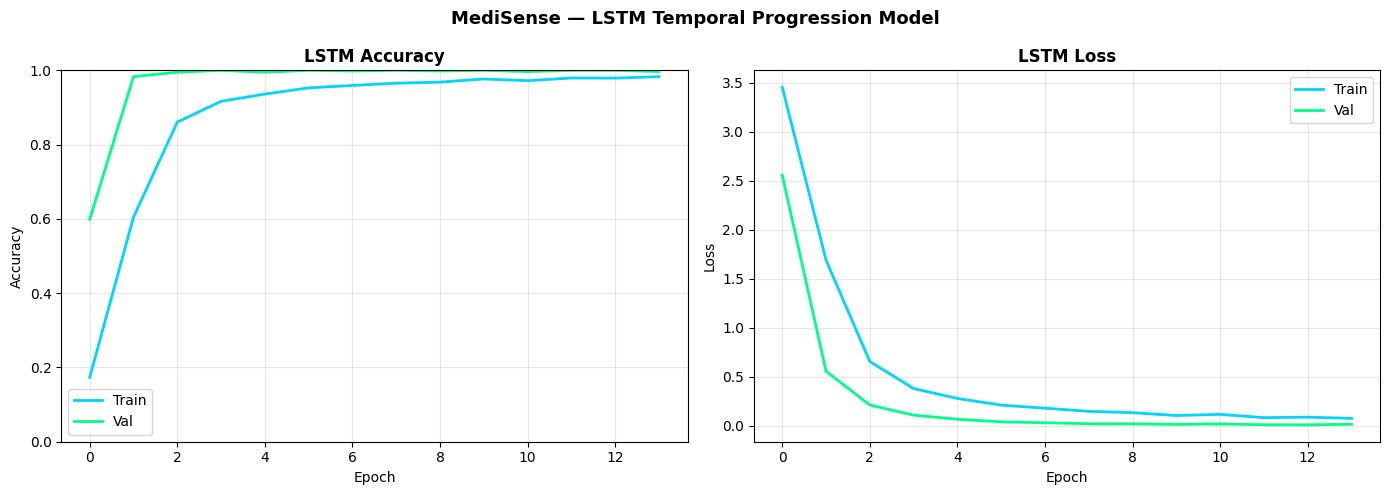

✓ Saved lstm_training_curves.png


In [7]:
# ── Training Curves ───────────────────────────────────────
OUT_IMG = Path('../backend/data/processed')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train', color='#00d4ff', lw=2)
ax1.plot(history.history['val_accuracy'], label='Val',   color='#00ff88', lw=2)
ax1.set_title('LSTM Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim(0, 1)

ax2.plot(history.history['loss'],     label='Train', color='#00d4ff', lw=2)
ax2.plot(history.history['val_loss'], label='Val',   color='#00ff88', lw=2)
ax2.set_title('LSTM Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('MediSense — LSTM Temporal Progression Model', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_IMG / 'lstm_training_curves.png', dpi=150)
plt.show()
print('✓ Saved lstm_training_curves.png')

In [8]:
# ── Classification Report ─────────────────────────────────
y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
print(classification_report(y_te_raw, y_pred, target_names=le.classes_))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00        24
                           

In [9]:
# ── Save LSTM Model ───────────────────────────────────────
model.save(MODEL_DIR / 'lstm_model.keras')

with open(MODEL_DIR / 'lstm_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

lstm_config = {
    'max_days':      MAX_DAYS,
    'n_symptoms':    N_SYMPTOMS,
    'n_classes':     N_CLASSES,
    'test_accuracy': float(acc),
    'diseases':      list(le.classes_)
}
with open(MODEL_DIR / 'lstm_config.json', 'w') as f:
    json.dump(lstm_config, f, indent=2)

print('Models saved to backend/data/models/')
print('  ✓ lstm_model.keras')
print('  ✓ lstm_label_encoder.pkl')
print('  ✓ lstm_config.json')

Models saved to backend/data/models/
  ✓ lstm_model.keras
  ✓ lstm_label_encoder.pkl
  ✓ lstm_config.json


In [10]:
# ── Test Temporal Prediction ──────────────────────────────
def predict_temporal(day_symptom_list, top_n=3):
    """
    day_symptom_list: list of lists, one per day
    e.g. [['mild_fever'], ['high_fever','cough'], ['breathlessness']]
    """
    seq = np.zeros((MAX_DAYS, N_SYMPTOMS))
    for day_idx, syms in enumerate(day_symptom_list[:MAX_DAYS]):
        for s in syms:
            if s in all_symptoms:
                seq[day_idx][all_symptoms.index(s)] = 1.0
    proba   = model.predict(seq[np.newaxis], verbose=0)[0]
    top_idx = np.argsort(proba)[::-1][:top_n]
    return [(le.classes_[i], f'{proba[i]*100:.1f}%') for i in top_idx]

print('Test 1 — Fever→Cough→Breathlessness (expect Pneumonia/TB/Asthma):')
print(predict_temporal([['mild_fever'], ['cough','high_fever'], ['breathlessness','sweating']]))

print('\nTest 2 — Chills→Fever→Sweating (expect Malaria):')
print(predict_temporal([['chills','shivering'], ['high_fever','headache'], ['sweating','vomiting']]))

print('\nTest 3 — Itching→Rash→Red spots (expect Chicken pox/Fungal):')
print(predict_temporal([['itching','mild_fever'], ['skin_rash','fatigue'], ['red_spots_over_body']]))

Test 1 — Fever→Cough→Breathlessness (expect Pneumonia/TB/Asthma):
[('Pneumonia', '40.4%'), ('Tuberculosis', '36.6%'), ('Bronchial Asthma', '12.7%')]

Test 2 — Chills→Fever→Sweating (expect Malaria):
[('Malaria', '95.3%'), ('Allergy', '1.3%'), ('Typhoid', '1.2%')]

Test 3 — Itching→Rash→Red spots (expect Chicken pox/Fungal):
[('Chicken pox', '61.3%'), ('Pneumonia', '11.6%'), ('AIDS', '4.6%')]


In [11]:
# ── Final Model Comparison Table (for paper) ─────────────
with open(MODEL_DIR / 'metrics.json') as f:
    rf_metrics = json.load(f)

print('=' * 50)
print('   MODEL COMPARISON — MediSense Pipeline')
print('=' * 50)
print(f"  Random Forest  : {rf_metrics['random_forest']['test_accuracy']*100:.2f}%")
print(f"  SVM            : {rf_metrics['svm']['test_accuracy']*100:.2f}%")
print(f"  LSTM (Temporal): {acc*100:.2f}%")
print('=' * 50)
print('  Copy these numbers into your paper Table 2!')

# Save combined metrics
paper_metrics = {
    'models': {
        'Random Forest': rf_metrics['random_forest']['test_accuracy'],
        'SVM':           rf_metrics['svm']['test_accuracy'],
        'LSTM Temporal': float(acc)
    },
    'dataset': {
        'diseases': rf_metrics['n_diseases'],
        'symptoms': rf_metrics['n_symptoms'],
        'samples':  rf_metrics['n_samples']
    }
}
with open(MODEL_DIR / 'paper_metrics.json', 'w') as f:
    json.dump(paper_metrics, f, indent=2)
print('\n✓ Saved paper_metrics.json')
print('\nAll models ready! Now run the backend and test the full app.')

   MODEL COMPARISON — MediSense Pipeline
  Random Forest  : 98.90%
  SVM            : 98.66%
  LSTM (Temporal): 100.00%
  Copy these numbers into your paper Table 2!

✓ Saved paper_metrics.json

All models ready! Now run the backend and test the full app.
